<a href="https://colab.research.google.com/github/alfadder/ProgForDataAnalysis/blob/main/Programming_For_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports essential libraries for data manipulation, analysis, and visualization, including pandas, numpy, sklearn, matplotlib, plotly, and seaborn.

In [2]:
import pandas as pd
import numpy as np
import os
import sklearn as sk
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

These commands configure global Git user settings (name and email), which are typically used for committing changes to a repository.

In [3]:
! git config --global user.name "alfadder" # replace with your username that you used to create the Github account
! git config --global user.email "alfadder@gmail.com" # and the email id which you have used to create account

This cell defines Python variables for the GitHub username and the repository name. These variables will be used in subsequent Git operations.

In [4]:
username = "alfadder" #replace with your own user name
repo = "ProgForDataAnalysis"  #replace with your required repo

This command clones the specified GitHub repository into your Colab environment, making the repository's files accessible.

In [5]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'ProgForDataAnalysis'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 15 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 2.87 MiB | 5.96 MiB/s, done.
Resolving deltas: 100% (5/5), done.


This command changes the current working directory to the newly cloned repository, allowing direct access to its contents.

In [6]:
%cd {repo}

/content/ProgForDataAnalysis


This command lists the files and directories within the current working directory (the cloned repository), confirming the successful cloning.

In [7]:
%ls

Programming_For_Data_Analysis.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv


This cell reads multiple city-specific CSV files, combines them into a single pandas DataFrame named `df`, saves the combined data to a new CSV file, and then displays the first few rows of the combined DataFrame.

In [8]:
import pandas as pd
import glob

city_files = glob.glob("*.csv")
all_cities_data = []

for file_name in city_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("all_cities_combined.csv", index=False)
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

df= pd.read_csv('all_cities_combined.csv')
df


Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


This code calculates and displays the count of unique values in the 'station' column of the `df` DataFrame, showing how many entries exist for each station.

In [9]:
stations = df['station'].value_counts()
stations

,count
station,
Dingling,35064
Dongsi,35064
Gucheng,35064
Huairou,35064


This cell creates a new 'date' column by combining the 'year', 'month', 'day', and 'hour' columns into a single datetime object, which is crucial for time-series analysis.

In [10]:
import pandas as pd
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling,2013-03-01 04:00:00


This cell generates a heatmap to visually represent missing values across the DataFrame before any imputation, providing an overview of data completeness. It also shows descriptive statistics for all numerical columns.

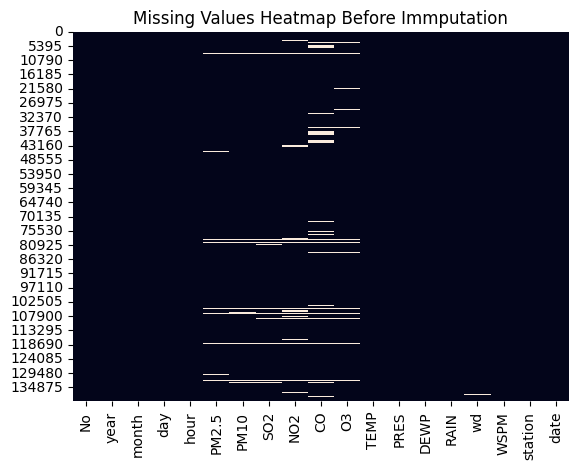

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475,NaN


In [11]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap Before Immputation')
plt.show()
df.describe()

This code identifies all numerical columns in the DataFrame that contain missing values, which are the target columns for the subsequent imputation steps.

In [12]:
numerical_df = df.select_dtypes(include=np.number)
missing_values_count = numerical_df.isnull().sum()
numerical_cols_with_missing_values = missing_values_count[missing_values_count > 0].index.tolist()

print("Numerical columns with missing values:")
print(numerical_cols_with_missing_values)

Numerical columns with missing values:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


This cell performs a two-step grouped mean imputation for numerical columns. It first fills missing values by grouping by 'station', 'year', and 'month', and then specifically imputes any remaining 'CO' missing values by grouping by 'station' and 'month'.

In [13]:
for col in numerical_cols_with_missing_values:
    df[col] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])[col].transform(lambda x: x.fillna(x.mean()))

# Impute remaining 'CO' values by station and month for cases where entire months were missing
if 'CO' in numerical_cols_with_missing_values and df['CO'].isnull().any():
    df['CO'] = df.groupby(['station', df['date'].dt.month])['CO'].transform(lambda x: x.fillna(x.mean()))

print("Missing values after grouped mean imputation:")
print(df[numerical_cols_with_missing_values].isnull().sum())

Missing values after grouped mean imputation:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


This code prints a summary of all remaining missing values across the entire DataFrame after the numerical imputation steps, highlighting columns that still have nulls (e.g., 'wd').

In [14]:
print("Remaining missing values after grouped mean imputation:")
print(df.isnull().sum())

Remaining missing values after grouped mean imputation:
No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2          0
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd         679
WSPM         0
station      0
date         0
dtype: int64


This cell displays the complete `df` DataFrame after the numerical imputation, allowing you to view the current state of the data.

In [15]:
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,3.0,48.238364,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
1,2,2013,3,1,1,7.0,7.0,3.0,48.238364,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,5.0,3.0,2.000000,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,3.0,48.238364,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,5.0,3.0,48.238364,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.000000,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou,2017-02-28 19:00:00
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.000000,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou,2017-02-28 20:00:00
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.000000,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou,2017-02-28 21:00:00
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.000000,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,2017-02-28 22:00:00


This cell defines a list of column names (`gas_columns`) that represent various gas measurements, preparing for specific operations on these columns.

In [16]:
gas_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print("Identified gas columns:")
print(gas_columns)

Identified gas columns:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


This code selects the defined `gas_columns`, rounds their values to one decimal place, and displays the resulting formatted DataFrame, providing a clean view of the gas measurement data.

In [17]:
formatted_gas_data = df[gas_columns].round(1)
print("Formatted gas measurement columns (rounded to 1 decimal place):")
formatted_gas_data

Formatted gas measurement columns (rounded to 1 decimal place):


,PM2.5,PM10,SO2,NO2,CO,O3
0,4.0,4.0,3.0,48.2,200.0,82.0
1,7.0,7.0,3.0,48.2,200.0,80.0
2,5.0,5.0,3.0,2.0,200.0,79.0
3,6.0,6.0,3.0,48.2,200.0,79.0
4,5.0,5.0,3.0,48.2,200.0,81.0
...,...,...,...,...,...,...
140251,16.0,28.0,2.0,19.0,300.0,95.0
140252,21.0,34.0,4.0,24.0,500.0,80.0
140253,17.0,33.0,2.0,39.0,900.0,60.0
140254,11.0,29.0,3.0,32.0,1400.0,69.0


This cell performs a two-step grouped mode imputation for the categorical 'wd' column. It first fills missing values by grouping by 'station', 'year', and 'month', and then by 'station' and 'month' for any remaining nulls, ensuring 'wd' is fully imputed.

In [18]:
print("Missing values in 'wd' before imputation:")
print(df['wd'].isnull().sum())

# Impute missing values in 'wd' by grouping by 'station', 'year', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Impute remaining missing values in 'wd' by grouping by 'station', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

print("\nMissing values in 'wd' after grouped mode imputation:")
print(df['wd'].isnull().sum())

print("\nRemaining missing values in the entire DataFrame:")
print(df.isnull().sum())

Missing values in 'wd' before imputation:
679

Missing values in 'wd' after grouped mode imputation:
0

Remaining missing values in the entire DataFrame:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


This cell displays a heatmap of missing values for the final DataFrame, which should be entirely blank if all imputations were successful. It also provides descriptive statistics for the fully imputed dataset.

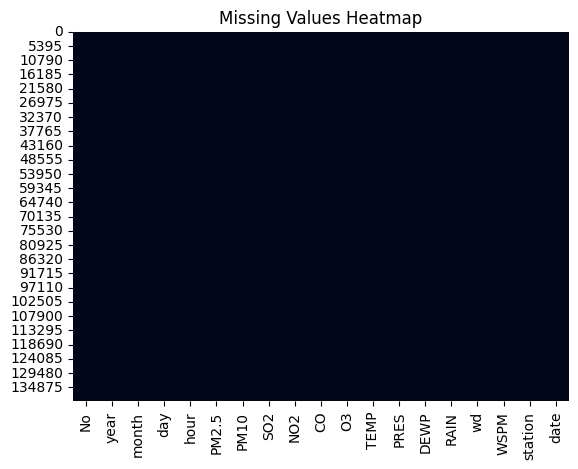

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.418775,101.142820,14.447132,42.427050,1149.245679,61.039722,13.405744,1009.191585,2.187762,0.064145,1.677643,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,500.000000,17.000000,3.000000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,53.000000,79.000000,6.000000,34.000000,900.000000,51.000000,14.400000,1008.900000,2.600000,0.000000,1.300000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,142.000000,18.000000,61.000000,1400.000000,86.000000,23.100000,1017.300000,14.900000,0.000000,2.100000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.600000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.212436,90.272532,19.902119,33.148722,1052.332571,55.560721,11.483923,10.347359,13.875769,0.807177,1.253877,NaN


In [19]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()
df.describe()

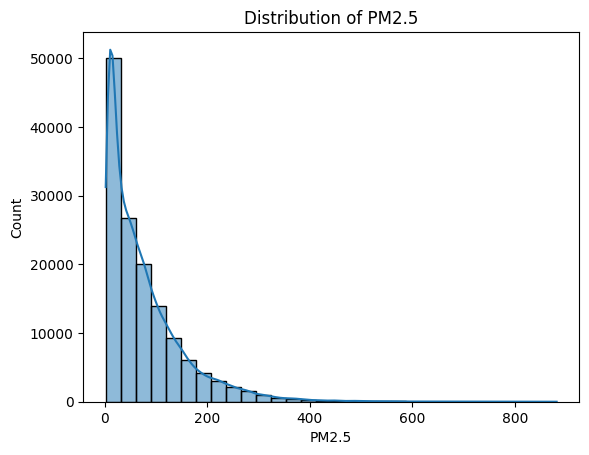

In [23]:
import seaborn as sns
sns.histplot(data=df, x="PM2.5", bins=30, kde=True)
title = "Distribution of PM2.5"
plt.title(title)
plt.show()

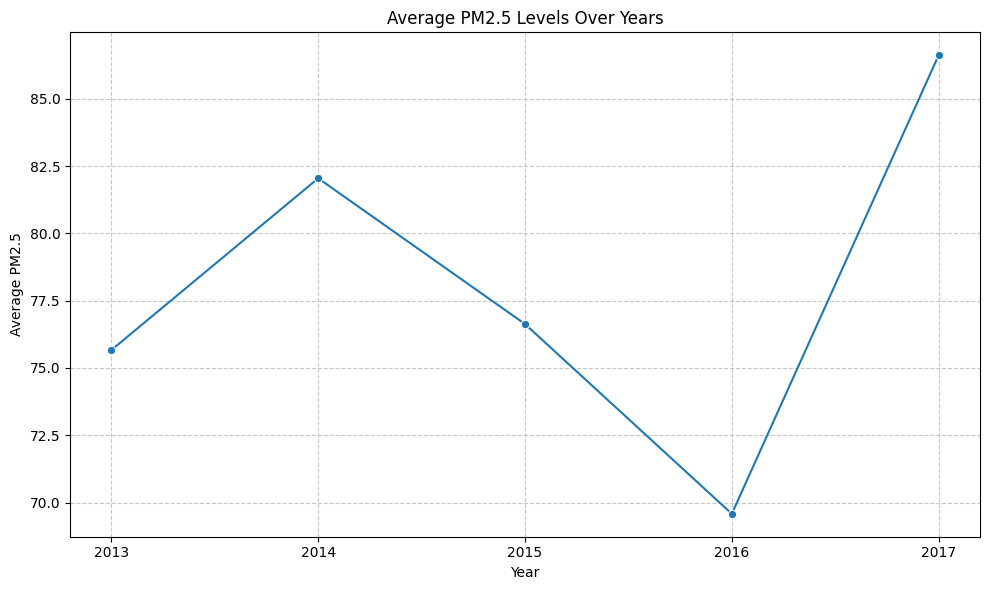

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_avg_pm25 = df.groupby('year')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='PM2.5', data=yearly_avg_pm25, marker='o')
plt.title('Average PM2.5 Levels Over Years')
plt.xlabel('Year')
plt.ylabel('Average PM2.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_avg_pm25['year'].unique())
plt.tight_layout()
plt.show()

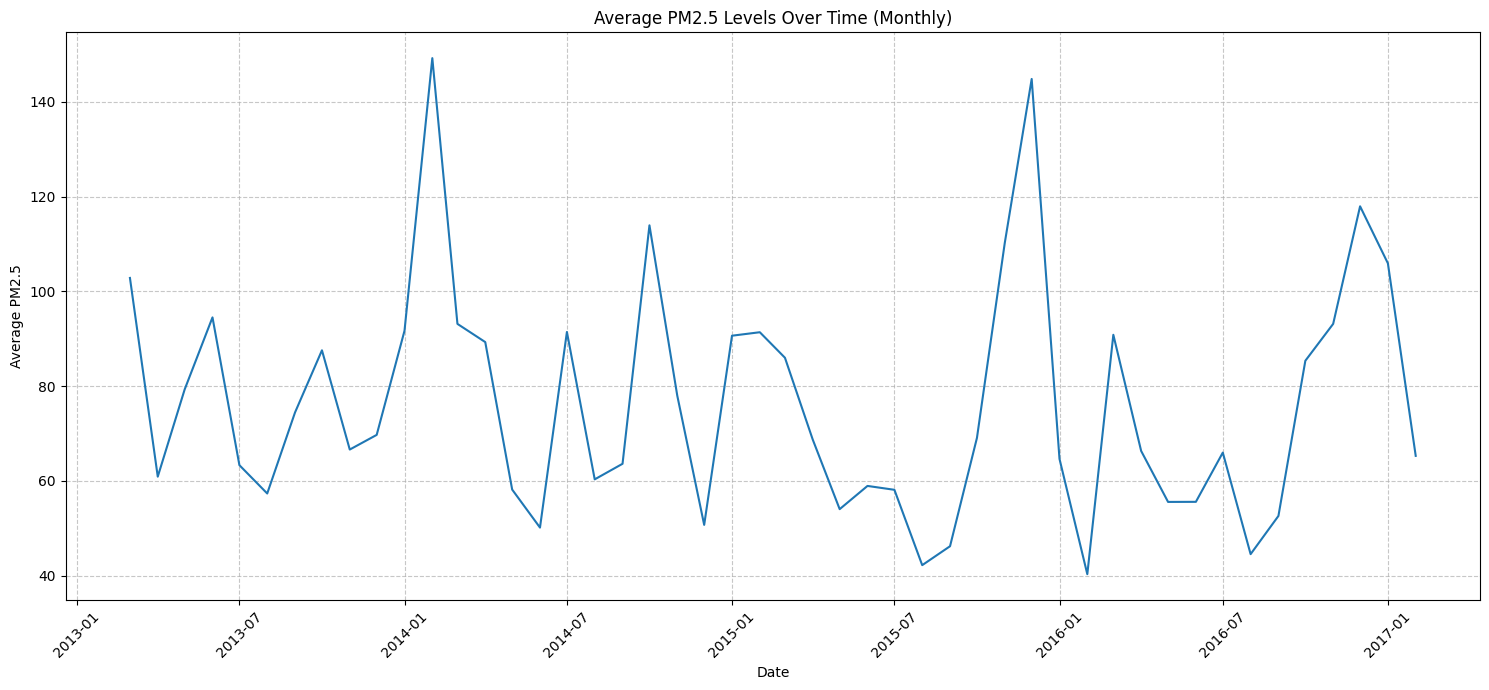

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'month_start_date' column for plotting each month across years
df['month_start_date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Group by this new monthly date and calculate the mean PM2.5
monthly_pm25_over_time = df.groupby('month_start_date')['PM2.5'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='month_start_date', y='PM2.5', data=monthly_pm25_over_time)
plt.title('Average PM2.5 Levels Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Average PM2.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
monthly_avg_gas_levels = df.groupby(['station', 'month_start_date'])[gas_columns].mean().reset_index()
print("Monthly Average Gas Levels by Station:")
monthly_avg_gas_levels.head()

Monthly Average Gas Levels by Station:


,station,month_start_date,PM2.5,PM10,SO2,NO2,CO,O3
0,Dingling,2013-03-01,95.705645,110.311231,24.358088,48.238364,1015.409859,68.141251
1,Dingling,2013-04-01,55.206506,80.148936,13.725471,26.967120,635.846726,73.853376
2,Dingling,2013-05-01,71.402266,114.093220,17.413140,28.586733,766.922619,97.733500
3,Dingling,2013-06-01,85.520950,87.280112,7.829724,20.992806,1145.575403,81.439421
4,Dingling,2013-07-01,54.012676,56.859773,4.191483,15.649809,759.668666,81.595652


In [28]:
fig = px.line(
    monthly_avg_gas_levels,
    x='month_start_date',
    y=gas_columns,
    color='station',
    facet_col='station',
    facet_col_wrap=2,
    title='Monthly Average Gas Levels Over Time by Station',
    labels={
        'month_start_date': 'Date',
        'value': 'Average Level',
        'variable': 'Gas Type'
    }
)
fig.update_layout(height=800, width=1000)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()


In [29]:
for gas_type in gas_columns:
    fig = px.line(
        monthly_avg_gas_levels,
        x='month_start_date',
        y=gas_type,
        color='station',
        title=f'Monthly Average {gas_type} Levels Over Time by Station',
        labels={
            'month_start_date': 'Date',
            gas_type: f'Average {gas_type} Level',
            'station': 'Station'
        }
    )
    fig.update_layout(height=500, width=800) # Adjust plot size for better readability
    fig.show()
